# Deteksi Jenis Sampah di Sekitar Kampus Menggunakan Convolutional Neural Network (CNN)

**Mata Kuliah:** Machine Learning / Deep Learning
**Topik:** Image Classification dengan CNN
**Dataset:** 6 kelas sampah (Cardboard, Glass, Metal, Paper, Plastic, Trash)

---

Notebook ini disusun secara akademik, dimulai dari penjelasan teori dasar Machine Learning dan Deep Learning, teori arsitektur CNN, hingga implementasi penuh model klasifikasi gambar jenis sampah menggunakan TensorFlow/Keras.


## 1. Pendahuluan

### 1.1 Apa itu Machine Learning?

**Machine Learning (ML)** adalah cabang dari kecerdasan buatan (*Artificial Intelligence*) yang memungkinkan sistem komputer untuk belajar dari data dan pengalaman tanpa diprogram secara eksplisit untuk setiap tugas. Alih-alih menuliskan aturan secara manual, model ML dilatih menggunakan data historis sehingga ia dapat menemukan pola dan membuat prediksi atau keputusan terhadap data baru yang belum pernah dilihat sebelumnya.

Secara umum, Machine Learning dibagi menjadi tiga kategori utama:
- **Supervised Learning** — model dilatih menggunakan data berlabel (contoh: klasifikasi, regresi).
- **Unsupervised Learning** — model mencari pola tersembunyi dari data tanpa label (contoh: clustering).
- **Reinforcement Learning** — model belajar melalui interaksi dengan lingkungan berdasarkan sistem reward dan punishment.

### 1.2 Apa itu Deep Learning?

**Deep Learning (DL)** adalah subbidang dari Machine Learning yang menggunakan **Artificial Neural Network (ANN)** dengan banyak lapisan (*layer*) tersembunyi untuk mempelajari representasi data secara hierarkis. Istilah "deep" merujuk pada kedalaman jaringan, yaitu banyaknya lapisan yang menyusun arsitektur model.

Keunggulan utama Deep Learning dibandingkan ML konvensional adalah kemampuannya melakukan **automatic feature extraction**, sehingga tidak diperlukan proses *feature engineering* manual seperti pada algoritma ML klasik (misalnya KNN, SVM, atau Random Forest).

### 1.3 Apa itu Computer Vision?

**Computer Vision (CV)** adalah bidang ilmu yang berfokus pada bagaimana komputer dapat "melihat" dan memahami informasi visual dari gambar atau video, layaknya sistem visual manusia. Computer Vision mencakup berbagai tugas seperti deteksi objek (*object detection*), segmentasi gambar (*image segmentation*), dan klasifikasi gambar (*image classification*).

### 1.4 Apa itu Image Classification?

**Image Classification** adalah tugas dalam Computer Vision yang bertujuan untuk memberikan label kategori terhadap sebuah gambar berdasarkan kontennya. Proses ini melibatkan ekstraksi fitur visual (tepi, tekstur, bentuk, warna) dari gambar, kemudian memetakan fitur tersebut ke salah satu kelas yang telah ditentukan.

### 1.5 Mengapa CNN Cocok untuk Klasifikasi Citra?

**Convolutional Neural Network (CNN)** dirancang khusus untuk mengolah data yang memiliki struktur grid seperti gambar (2D) atau video (3D). Beberapa alasan utama CNN sangat cocok digunakan untuk klasifikasi citra:

1. **Local connectivity** — setiap neuron pada layer konvolusi hanya terhubung dengan area lokal dari input (*receptive field*), sehingga mampu menangkap pola spasial seperti tepi dan tekstur.
2. **Parameter sharing** — kernel/filter yang sama digunakan di seluruh area gambar, sehingga jumlah parameter jauh lebih efisien dibandingkan *fully connected network* biasa.
3. **Translation invariance** — CNN dapat mengenali objek meskipun posisinya bergeser dalam gambar, berkat operasi pooling.
4. **Hierarchical feature learning** — layer awal mempelajari fitur sederhana (tepi, garis), sedangkan layer yang lebih dalam mempelajari fitur kompleks (bentuk, objek utuh).

### 1.6 Tujuan Proyek

Proyek ini bertujuan untuk membangun sebuah model CNN yang dapat **mengklasifikasikan jenis sampah di sekitar kampus** ke dalam 6 kategori: *cardboard, glass, metal, paper, plastic,* dan *trash*. Sistem klasifikasi otomatis ini diharapkan dapat menjadi dasar bagi pengembangan sistem **pemilahan sampah otomatis** berbasis visi komputer, yang dapat mendukung pengelolaan sampah yang lebih efisien dan ramah lingkungan di lingkungan kampus.


## 2. Penjelasan Teori CNN

Arsitektur CNN secara umum tersusun dari beberapa jenis layer yang bekerja secara berurutan untuk mengubah gambar mentah menjadi prediksi kelas. Berikut adalah alur kerja umum CNN:

```
Input Image
   |
   v
Convolution Layer  --> mengekstraksi fitur (tepi, tekstur, pola)
   |
   v
ReLU (Activation)  --> menambahkan non-linearitas
   |
   v
Pooling Layer      --> mereduksi dimensi spasial, mempertahankan fitur penting
   |
   v
 (ulangi blok Conv -> ReLU -> Pooling beberapa kali)
   |
   v
Flatten Layer       --> mengubah feature map 2D/3D menjadi vektor 1D
   |
   v
Dense Layer (FC)    --> mempelajari kombinasi fitur tingkat tinggi
   |
   v
Dropout              --> mencegah overfitting
   |
   v
Output Layer (Softmax) --> menghasilkan probabilitas tiap kelas
   |
   v
Predicted Class
```

### 2.1 Convolution Layer

**Convolution** adalah operasi matematis yang menggeser sebuah **kernel/filter** kecil (misalnya 3x3 atau 5x5) di sepanjang gambar input untuk menghasilkan **feature map**. Setiap posisi kernel melakukan perkalian elemen-demi-elemen (*element-wise multiplication*) dengan area gambar yang ditumpanginya, kemudian hasilnya dijumlahkan menjadi satu nilai output.

- **Kernel/Filter**: matriks bobot kecil yang nilainya dipelajari selama proses training. Setiap filter bertugas mendeteksi pola visual tertentu, seperti tepi vertikal, tepi horizontal, atau tekstur tertentu.
- **Feature Extraction**: melalui proses convolution berulang, jaringan secara otomatis mempelajari fitur-fitur penting dari gambar tanpa perlu rekayasa fitur manual. Semakin dalam layer, semakin kompleks fitur yang ditangkap (dari tepi sederhana hingga bentuk objek).
- **Stride** menentukan seberapa jauh kernel bergeser setiap langkah, dan **padding** menentukan apakah tepi gambar perlu ditambah nilai nol agar ukuran output dapat dikontrol.

### 2.2 Activation Function

Fungsi aktivasi memberikan **non-linearitas** pada jaringan sehingga model dapat mempelajari hubungan yang kompleks, bukan hanya hubungan linear.

- **ReLU (Rectified Linear Unit)**: didefinisikan sebagai `f(x) = max(0, x)`. ReLU mengubah seluruh nilai negatif menjadi nol dan mempertahankan nilai positif apa adanya. ReLU populer digunakan pada hidden layer CNN karena komputasinya sederhana dan efektif mengatasi masalah *vanishing gradient* dibandingkan fungsi sigmoid/tanh.
- **Softmax**: digunakan pada layer output untuk masalah klasifikasi multi-kelas. Softmax mengubah skor mentah (*logits*) menjadi distribusi probabilitas di mana seluruh nilai output berada pada rentang 0–1 dan jumlah totalnya sama dengan 1. Kelas dengan probabilitas tertinggi dipilih sebagai prediksi akhir.

### 2.3 Pooling Layer

Pooling berfungsi untuk **mereduksi dimensi spasial** dari feature map sehingga mengurangi jumlah parameter dan komputasi, sekaligus membuat fitur yang dipelajari menjadi lebih tahan terhadap pergeseran posisi objek (*translation invariance*).

- **Max Pooling**: mengambil nilai maksimum dari setiap area kecil (misalnya 2x2) pada feature map. Max pooling efektif mempertahankan fitur paling menonjol (misalnya tepi yang kuat).
- **Average Pooling**: mengambil nilai rata-rata dari setiap area kecil. Average pooling menghasilkan representasi yang lebih halus namun dapat menghilangkan detail fitur yang tajam.

Pada proyek ini digunakan **Max Pooling** karena lebih umum digunakan untuk tugas klasifikasi citra dan terbukti mempertahankan fitur diskriminatif dengan baik.

### 2.4 Flatten Layer

Setelah melalui beberapa blok convolution dan pooling, feature map yang berbentuk tensor 3D (*height x width x channel*) perlu diubah menjadi **vektor 1D** agar dapat diproses oleh layer Dense (*Fully Connected*). Inilah fungsi dari **Flatten Layer**, yaitu meratakan seluruh elemen tensor menjadi satu rangkaian vektor tanpa mengubah nilainya.

### 2.5 Fully Connected Layer (Dense Layer)

Dense Layer adalah layer di mana setiap neuron terhubung dengan seluruh neuron pada layer sebelumnya. Layer ini bertugas mempelajari **kombinasi fitur tingkat tinggi** dari hasil ekstraksi fitur sebelumnya untuk membantu proses pengambilan keputusan klasifikasi akhir.

### 2.6 Output Layer

Output layer pada kasus klasifikasi multi-kelas terdiri dari neuron sebanyak jumlah kelas (dalam proyek ini 6 neuron, mewakili *cardboard, glass, metal, paper, plastic, trash*) dengan fungsi aktivasi **Softmax**. Hasil akhirnya berupa distribusi probabilitas untuk setiap kelas, di mana kelas dengan nilai probabilitas tertinggi dipilih sebagai hasil prediksi.


## 3. Import Library

Pada bagian ini diimpor seluruh pustaka (*library*) yang digunakan sepanjang notebook, meliputi pustaka untuk manipulasi data, visualisasi, pemrosesan gambar, serta pembangunan dan evaluasi model deep learning.


In [1]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

# Library dasar untuk manipulasi data dan komputasi numerik
import os
import random
import numpy as np
import pandas as pd

# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library pemrosesan gambar
import cv2
from PIL import Image

# Library Scikit-Learn untuk preprocessing & evaluasi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Library TensorFlow / Keras untuk membangun model CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ==========================================================
# RANDOM SEED -> agar hasil eksperimen dapat direproduksi
# ==========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version :", tf.__version__)
print("Seed berhasil diatur ke:", SEED)


TensorFlow version : 2.21.0
Seed berhasil diatur ke: 42


## 4. Load Dataset

Dataset yang digunakan terdiri dari 6 kelas jenis sampah: **Cardboard, Glass, Metal, Paper, Plastic,** dan **Trash**. Struktur folder dataset adalah sebagai berikut:

```
dataset/
├── cardboard/
├── glass/
├── metal/
├── paper/
├── plastic/
└── trash/
```

> **Catatan:** Sesuaikan variabel `DATASET_DIR` di bawah ini dengan lokasi dataset Anda. Jika menjalankan di Google Colab, dataset dapat diunggah ke Google Drive lalu di-mount, atau diunduh langsung dari Kaggle menggunakan Kaggle API.


In [2]:
# ==========================================================
# KONFIGURASI PATH DATASET
# ==========================================================
# Ganti path berikut sesuai lokasi dataset pada sistem Anda
# (lokal maupun Google Colab)

DATASET_DIR = "TrashType_Image_Dataset"

CLASS_NAMES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
NUM_CLASSES = len(CLASS_NAMES)

# Validasi keberadaan folder dataset agar tidak terjadi error
if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(
        f"Folder dataset '{DATASET_DIR}' tidak ditemukan. "
        f"Pastikan path dataset sudah benar dan berisi subfolder per kelas: {CLASS_NAMES}"
    )

print("Dataset ditemukan pada:", os.path.abspath(DATASET_DIR))


Dataset ditemukan pada: c:\Users\broig\Documents\SEMESTER 6\Machine Learning 603\Week 12 - Introduction to CNN\Practice Assignment - 9\TrashType_Image_Dataset


In [3]:
# ==========================================================
# MENGHITUNG JUMLAH GAMBAR PER KELAS
# ==========================================================

class_counts = {}
for class_name in CLASS_NAMES:
    class_path = os.path.join(DATASET_DIR, class_name)
    if os.path.exists(class_path):
        n_images = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[class_name] = n_images
    else:
        class_counts[class_name] = 0
        print(f"Peringatan: folder '{class_name}' tidak ditemukan.")

df_counts = pd.DataFrame(
    list(class_counts.items()), columns=["Kelas", "Jumlah Gambar"]
).sort_values("Jumlah Gambar", ascending=False)

print("Distribusi jumlah gambar per kelas:")
print(df_counts.to_string(index=False))
print("\nTotal gambar dalam dataset:", df_counts["Jumlah Gambar"].sum())


Distribusi jumlah gambar per kelas:
    Kelas  Jumlah Gambar
    paper            594
    glass            501
  plastic            482
    metal            410
cardboard            403
    trash            137

Total gambar dalam dataset: 2527


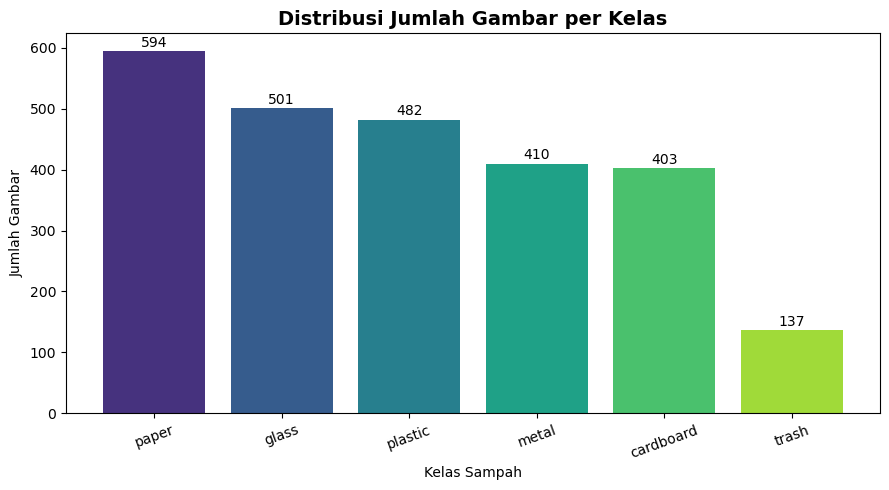

In [4]:
# ==========================================================
# VISUALISASI DISTRIBUSI DATASET (BAR CHART)
# ==========================================================

plt.figure(figsize=(9, 5))
bars = plt.bar(df_counts["Kelas"], df_counts["Jumlah Gambar"], color=sns.color_palette("viridis", len(df_counts)))
plt.title("Distribusi Jumlah Gambar per Kelas", fontsize=14, fontweight='bold')
plt.xlabel("Kelas Sampah")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=20)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 2, str(int(height)),
              ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## 5. Data Preprocessing

Tahap preprocessing bertujuan menyiapkan data mentah agar layak diproses oleh model CNN. Tahapan yang dilakukan meliputi:

1. **Resize image** menjadi 224x224 piksel — menyamakan ukuran seluruh gambar agar sesuai dengan input layer CNN yang membutuhkan dimensi tetap.
2. **Normalisasi pixel** (0–255 menjadi 0–1) — mempercepat dan menstabilkan proses training karena rentang nilai input menjadi lebih kecil dan konsisten, sehingga gradient lebih mudah dioptimasi.
3. **Label Encoding** — mengubah label kelas berupa teks (*string*) menjadi representasi numerik yang dapat diproses model, kemudian di-*one-hot encode* untuk klasifikasi multi-kelas dengan loss *categorical crossentropy*.
4. **Train-Validation-Test Split** dengan rasio 70:15:15 — memastikan model dievaluasi secara objektif menggunakan data yang belum pernah dilihat selama training maupun saat tuning hyperparameter (validation set).


In [5]:
# ==========================================================
# FUNGSI UNTUK MEMUAT DAN MERESIZE GAMBAR
# ==========================================================

IMG_SIZE = 224  # ukuran target resize (224 x 224)

def load_images_from_directory(dataset_dir, class_names, img_size=IMG_SIZE):
    """
    Memuat seluruh gambar dari folder dataset, melakukan resize,
    dan mengembalikan array gambar beserta labelnya.
    """
    images = []
    labels = []

    for class_name in class_names:
        class_path = os.path.join(dataset_dir, class_name)
        if not os.path.exists(class_path):
            continue

        image_files = [f for f in os.listdir(class_path)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        for file_name in image_files:
            img_path = os.path.join(class_path, file_name)
            try:
                # Membaca gambar menggunakan OpenCV (BGR -> RGB)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))

                images.append(img)
                labels.append(class_name)
            except Exception as e:
                print(f"Gagal memuat {img_path}: {e}")

    return np.array(images), np.array(labels)

print("Memuat dan melakukan resize seluruh gambar ke 224x224...")
X, y_text = load_images_from_directory(DATASET_DIR, CLASS_NAMES, IMG_SIZE)
print("Total gambar berhasil dimuat:", X.shape[0])
print("Bentuk array gambar         :", X.shape)


Memuat dan melakukan resize seluruh gambar ke 224x224...


Total gambar berhasil dimuat: 2527
Bentuk array gambar         : (2527, 224, 224, 3)


In [6]:
# ==========================================================
# NORMALISASI PIXEL (0-255 -> 0-1)
# ==========================================================

X = X.astype("float32") / 255.0
print("Rentang nilai pixel setelah normalisasi -> min:", X.min(), ", max:", X.max())


Rentang nilai pixel setelah normalisasi -> min: 0.0 , max: 1.0


In [7]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_text)   # contoh: 'cardboard' -> 0, 'glass' -> 1, dst.

print("Mapping label encoding:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"  {idx} -> {class_name}")

# One-hot encoding untuk loss categorical_crossentropy
y_onehot = to_categorical(y_encoded, num_classes=NUM_CLASSES)
print("\nBentuk label setelah one-hot encoding:", y_onehot.shape)


Mapping label encoding:
  0 -> cardboard
  1 -> glass
  2 -> metal
  3 -> paper
  4 -> plastic
  5 -> trash

Bentuk label setelah one-hot encoding: (2527, 6)


In [8]:
# ==========================================================
# TRAIN - VALIDATION - TEST SPLIT (70% : 15% : 15%)
# ==========================================================

# Tahap 1: pisahkan 70% data Train dan 30% data sisanya (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_onehot,
    test_size=0.30,
    random_state=SEED,
    stratify=y_encoded
)

# Tahap 2: bagi rata 30% sisa menjadi 15% Validation dan 15% Test
y_temp_labels = np.argmax(y_temp, axis=1)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp_labels
)

print("Jumlah data Train      :", X_train.shape[0])
print("Jumlah data Validation :", X_val.shape[0])
print("Jumlah data Test       :", X_test.shape[0])
print("Total                  :", X_train.shape[0] + X_val.shape[0] + X_test.shape[0])


Jumlah data Train      : 1768
Jumlah data Validation : 379
Jumlah data Test       : 380
Total                  : 2527


## 6. Data Augmentation

**Data Augmentation** adalah teknik untuk memperbanyak variasi data training secara artifisial dengan menerapkan transformasi acak pada gambar asli, seperti rotasi, zoom, flip, dan pergeseran (*shift*). Teknik ini sangat penting terutama ketika jumlah data terbatas, karena:

- **Mengurangi overfitting** — model tidak hanya menghafal piksel-piksel spesifik dari data training, melainkan mempelajari pola visual yang lebih general dan robust.
- **Meningkatkan generalisasi** — model menjadi lebih tahan terhadap variasi kondisi pengambilan gambar di dunia nyata (sudut pandang, pencahayaan, posisi objek).
- **Memperkaya distribusi data** tanpa perlu mengumpulkan data baru secara manual, yang tentunya menghemat waktu dan biaya.

Transformasi augmentasi yang digunakan pada proyek ini meliputi: **rotation, zoom, horizontal flip, width shift,** dan **height shift**.


In [9]:
# ==========================================================
# DATA AUGMENTATION (hanya diterapkan pada data TRAINING)
# ==========================================================

train_augmentor = ImageDataGenerator(
    rotation_range=30,        # rotasi acak hingga 30 derajat
    zoom_range=0.2,           # zoom in/out acak hingga 20%
    horizontal_flip=True,     # flip horizontal acak
    width_shift_range=0.15,   # pergeseran horizontal hingga 15%
    height_shift_range=0.15,  # pergeseran vertikal hingga 15%
    fill_mode='nearest'       # strategi pengisian piksel kosong hasil transformasi
)

# Data validation & test TIDAK diaugmentasi, hanya dilewatkan apa adanya,
# karena augmentasi hanya relevan untuk memperkaya proses belajar model.
val_test_augmentor = ImageDataGenerator()

BATCH_SIZE = 32

train_generator = train_augmentor.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_generator   = val_test_augmentor.flow(X_val, y_val, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)
test_generator  = val_test_augmentor.flow(X_test, y_test, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)

print("Data generator untuk Train, Validation, dan Test berhasil dibuat.")


Data generator untuk Train, Validation, dan Test berhasil dibuat.


## 7. Visualisasi Dataset

Bagian ini menampilkan beberapa contoh gambar dari setiap kelas pada dataset, serta hasil transformasi data augmentation, untuk memastikan proses pemuatan data dan augmentasi berjalan dengan benar secara visual.


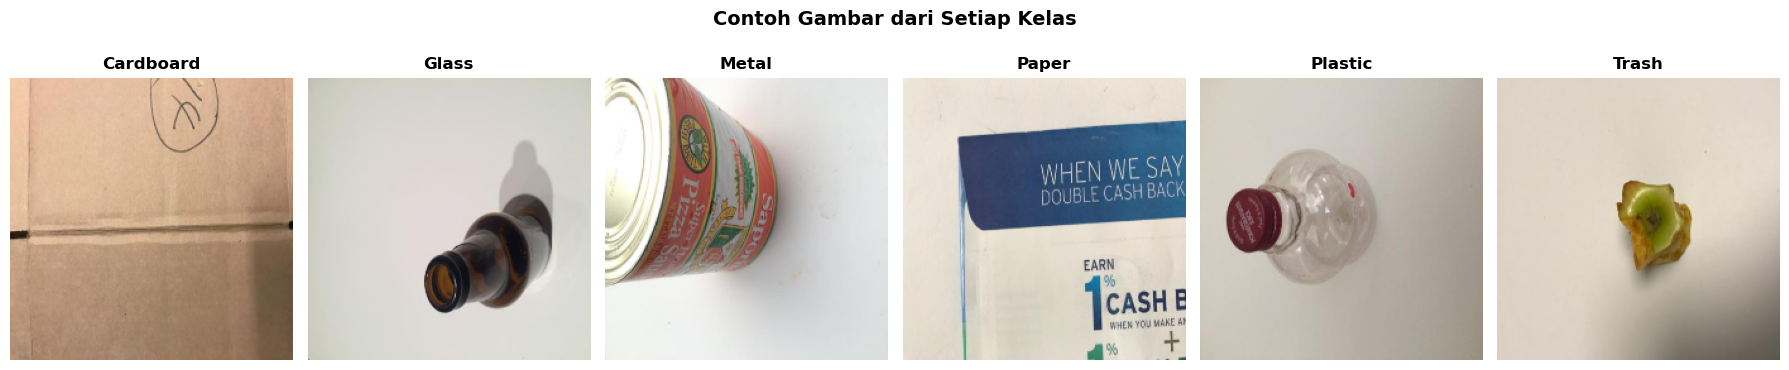

In [10]:
# ==========================================================
# CONTOH GAMBAR DARI MASING-MASING KELAS
# ==========================================================

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(18, 4))

for i, class_name in enumerate(CLASS_NAMES):
    idx = np.where(y_text == class_name)[0]
    if len(idx) > 0:
        sample_idx = idx[0]
        axes[i].imshow(X[sample_idx])
        axes[i].set_title(class_name.capitalize(), fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Contoh Gambar dari Setiap Kelas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


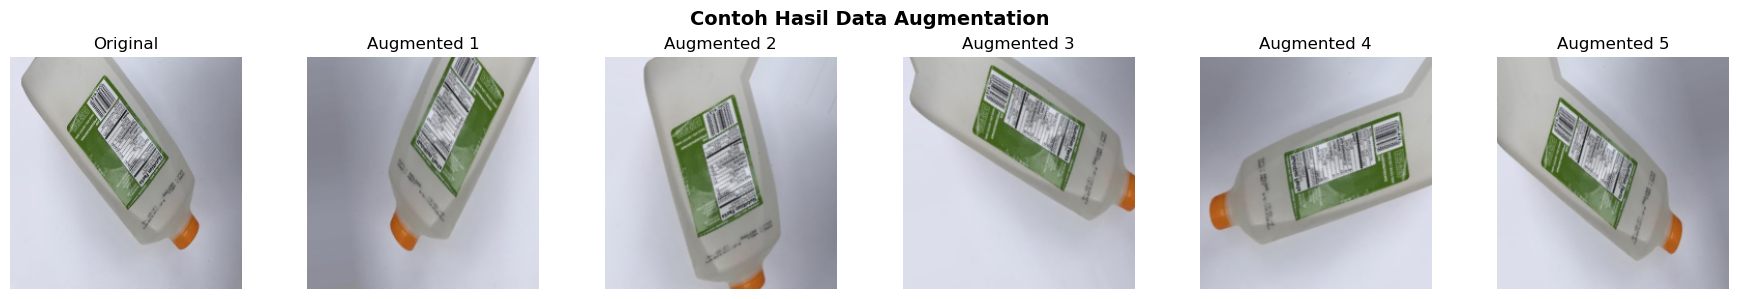

In [11]:
# ==========================================================
# VISUALISASI HASIL DATA AUGMENTATION
# ==========================================================

sample_image = np.expand_dims(X_train[0], axis=0)
augmentation_iterator = train_augmentor.flow(sample_image, batch_size=1, seed=SEED)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(X_train[0])
axes[0].set_title("Original")
axes[0].axis('off')

for i in range(1, 6):
    augmented_image = next(augmentation_iterator)[0]
    axes[i].imshow(augmented_image)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')

plt.suptitle("Contoh Hasil Data Augmentation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Membangun Model CNN

Model CNN pada proyek ini dibangun **dari awal (from scratch)**, bukan menggunakan *transfer learning*, sesuai dengan ketentuan proyek. Arsitektur model terdiri dari 3 blok convolutional, diikuti dengan flatten, dense layer, dropout, dan output layer.

Arsitektur:

```
Conv2D(32) + ReLU -> MaxPooling2D
Conv2D(64) + ReLU -> MaxPooling2D
Conv2D(128) + ReLU -> MaxPooling2D
Flatten
Dense(128) + ReLU
Dropout(0.5)
Dense(6) + Softmax
```

Penjelasan fungsi setiap layer akan diberikan setelah blok kode pembangunan model.


In [12]:
# ==========================================================
# MEMBANGUN ARSITEKTUR CNN DARI AWAL (FROM SCRATCH)
# ==========================================================

model = models.Sequential([
    # Blok Konvolusi 1: mendeteksi fitur dasar (tepi, garis, tekstur sederhana)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3), name='conv2d_block1'),
    layers.MaxPooling2D((2, 2), name='maxpool_block1'),

    # Blok Konvolusi 2: mendeteksi fitur yang lebih kompleks (pola, bentuk dasar)
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_block2'),
    layers.MaxPooling2D((2, 2), name='maxpool_block2'),

    # Blok Konvolusi 3: mendeteksi fitur tingkat tinggi (bentuk objek utuh)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv2d_block3'),
    layers.MaxPooling2D((2, 2), name='maxpool_block3'),

    # Flatten: mengubah feature map 3D menjadi vektor 1D
    layers.Flatten(name='flatten'),

    # Dense Layer: mempelajari kombinasi fitur tingkat tinggi untuk klasifikasi
    layers.Dense(128, activation='relu', name='dense_fc1'),

    # Dropout: menonaktifkan 50% neuron secara acak setiap iterasi training
    # untuk mencegah overfitting dan meningkatkan generalisasi model
    layers.Dropout(0.5, name='dropout'),

    # Output Layer: menghasilkan probabilitas untuk 6 kelas menggunakan Softmax
    layers.Dense(NUM_CLASSES, activation='softmax', name='output_layer')
], name='CNN_Waste_Classifier')

model.summary()


C:\Users\broig\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Waste_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_block1 (Conv2D)          │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block1 (MaxPooling2D)   │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_block2 (Conv2D)          │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block2 (MaxPooling2D)   │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_block3 (Conv2D)          │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block3 (MaxPooling2D)   │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_fc1 (Dense)               │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,206 (49.36 MB)

 Trainable params: 12,939,206 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

**Penjelasan fungsi setiap layer pada arsitektur di atas:**

| Layer | Fungsi |
|---|---|
| `Conv2D(32)` | Mengekstraksi 32 jenis fitur dasar dari gambar input (tepi, garis, kontras warna) menggunakan kernel 3x3. |
| `MaxPooling2D` | Mereduksi dimensi spasial feature map sebesar setengah pada setiap sumbu, mempertahankan fitur paling dominan, dan mengurangi beban komputasi. |
| `Conv2D(64)` | Mengekstraksi fitur yang lebih kompleks dari hasil blok sebelumnya, seperti kombinasi tepi menjadi pola tekstur. |
| `Conv2D(128)` | Mengekstraksi fitur tingkat tinggi yang merepresentasikan bagian-bagian objek utuh (misalnya bentuk khas botol plastik atau lipatan kardus). |
| `Flatten` | Mengubah output 3D (*height x width x channel*) menjadi vektor 1D agar dapat diproses oleh Dense Layer. |
| `Dense(128)` | Mempelajari kombinasi non-linear dari seluruh fitur yang telah diekstraksi untuk membantu proses klasifikasi akhir. |
| `Dropout(0.5)` | Menonaktifkan 50% neuron secara acak pada setiap iterasi training agar model tidak terlalu bergantung pada neuron tertentu (mencegah overfitting). |
| `Dense(6, softmax)` | Layer output yang menghasilkan distribusi probabilitas terhadap 6 kelas sampah. |


## 9. Training Model

Model dikompilasi menggunakan **Adam optimizer**, fungsi loss **categorical crossentropy** (karena merupakan klasifikasi multi-kelas dengan label one-hot encoded), dan metrik **accuracy**. Proses training dilakukan selama maksimum 20 epoch dengan ukuran batch 32.

Dua callback digunakan untuk meningkatkan efisiensi dan kualitas training:

- **EarlyStopping**: menghentikan training secara otomatis apabila *validation loss* tidak mengalami perbaikan selama beberapa epoch berturut-turut, untuk mencegah overfitting dan menghemat waktu komputasi.
- **ModelCheckpoint**: menyimpan bobot model terbaik (berdasarkan *validation accuracy* tertinggi) secara otomatis selama proses training berlangsung.


In [13]:
# ==========================================================
# KOMPILASI MODEL
# ==========================================================

model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 20

# ==========================================================
# CALLBACKS
# ==========================================================

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='best_waste_classifier.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks_list = [early_stopping, model_checkpoint]

print("Model berhasil dikompilasi. Memulai proses training...")


Model berhasil dikompilasi. Memulai proses training...


In [14]:
# ==========================================================
# PROSES TRAINING MODEL
# ==========================================================

history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=len(X_val) // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

print("\nProses training selesai.")


Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2372 - loss: 1.8272
Epoch 1: val_accuracy improved from None to 0.34943, saving model to best_waste_classifier.keras

Epoch 1: finished saving model to best_waste_classifier.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.2846 - loss: 1.6993 - val_accuracy: 0.3494 - val_loss: 1.5343
Epoch 2/20
 1/55 ━━━━━━━━━━━━━━━━━━━━ 23s 427ms/step - accuracy: 0.3125 - loss: 1.6770

C:\Users\broig\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.34943 to 0.35795, saving model to best_waste_classifier.keras

Epoch 2: finished saving model to best_waste_classifier.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3125 - loss: 1.6770 - val_accuracy: 0.3580 - val_loss: 1.5235
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.3389 - loss: 1.5893
Epoch 3: val_accuracy improved from 0.35795 to 0.37784, saving model to best_waste_classifier.keras

Epoch 3: finished saving model to best_waste_classifier.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 481ms/step - accuracy: 0.3399 - loss: 1.5863 - val_accuracy: 0.3778 - val_loss: 1.5743
Epoch 4/20
 1/55 ━━━━━━━━━━━━━━━━━━━━ 20s 378ms/step - accuracy: 0.3125 - loss: 1.5045
Epoch 4: val_accuracy improved from 0.37784 to 0.38920, saving model to best_waste_classifier.keras

Epoch 4: finished saving model to best_waste_classifier.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3125 - loss: 1.5045 - val_accuracy: 0.3892 - val_

## 10. Evaluasi Model

Evaluasi performa model dilakukan menggunakan data **Test** yang belum pernah dilihat sama sekali oleh model selama proses training maupun validasi. Metrik evaluasi yang digunakan meliputi:

- **Accuracy**: proporsi prediksi benar terhadap seluruh data.
- **Precision**: proporsi prediksi positif yang benar-benar positif (mengukur seberapa "tepat" model).
- **Recall**: proporsi data positif aktual yang berhasil dikenali model (mengukur seberapa "lengkap" model menangkap kelas tersebut).
- **F1-Score**: rata-rata harmonik antara precision dan recall, memberikan gambaran performa yang seimbang terutama jika distribusi kelas tidak merata.

Selain itu, ditampilkan **Classification Report** lengkap per kelas dan **Confusion Matrix** dalam bentuk heatmap untuk menganalisis pola kesalahan klasifikasi antar kelas.


In [15]:
# ==========================================================
# EVALUASI MODEL PADA DATA TEST
# ==========================================================

test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

# Prediksi seluruh data test
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


Test Loss     : 1.1260
Test Accuracy : 0.5553


In [16]:
# ==========================================================
# METRIK EVALUASI: ACCURACY, PRECISION, RECALL, F1-SCORE
# ==========================================================

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("===== HASIL EVALUASI MODEL =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


===== HASIL EVALUASI MODEL =====
Accuracy  : 0.5553
Precision : 0.5671
Recall    : 0.5553
F1-Score  : 0.5341


In [17]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

target_names = label_encoder.classes_
report = classification_report(y_true, y_pred, target_names=target_names, zero_division=0)
print("===== CLASSIFICATION REPORT =====")
print(report)


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

   cardboard       0.84      0.60      0.70        60
       glass       0.54      0.39      0.45        76
       metal       0.49      0.34      0.40        62
       paper       0.53      0.83      0.65        89
     plastic       0.51      0.67      0.58        73
       trash       0.50      0.05      0.09        20

    accuracy                           0.56       380
   macro avg       0.57      0.48      0.48       380
weighted avg       0.57      0.56      0.53       380



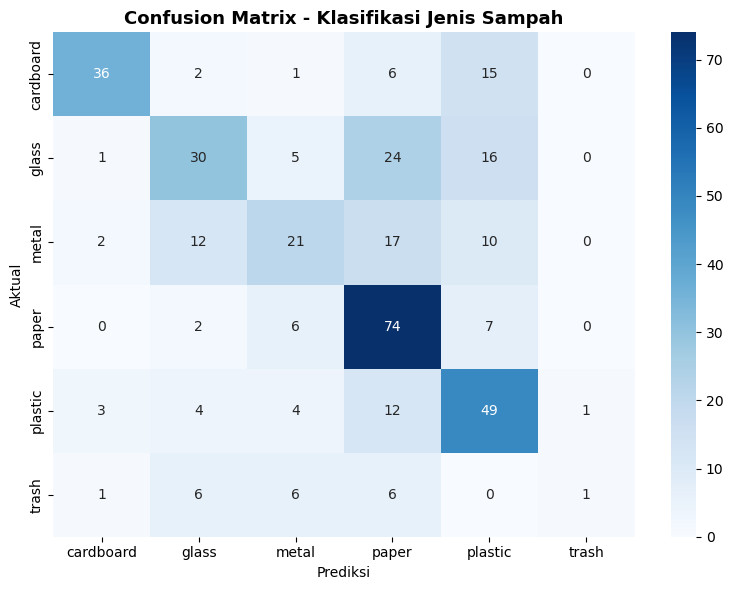

In [18]:
# ==========================================================
# CONFUSION MATRIX (HEATMAP)
# ==========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - Klasifikasi Jenis Sampah", fontsize=13, fontweight='bold')
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()


**Interpretasi hasil evaluasi:**

Nilai *accuracy*, *precision*, *recall*, dan *F1-score* yang ditampilkan di atas memberikan gambaran umum performa model dalam mengklasifikasikan 6 jenis sampah. *Confusion matrix* membantu mengidentifikasi pasangan kelas yang paling sering tertukar (misalnya antara `glass` dan `plastic` yang secara visual memiliki tekstur transparan/mengkilap yang serupa, atau antara `paper` dan `cardboard` yang memiliki warna dan tekstur yang mirip). Nilai diagonal pada confusion matrix yang tinggi menunjukkan performa klasifikasi yang baik untuk kelas tersebut, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi (*misclassification*) antar kelas.


## 11. Visualisasi Hasil Training

Grafik *training history* digunakan untuk memantau perkembangan performa model selama proses training, baik dari sisi **accuracy** maupun **loss**, pada data training maupun validation. Grafik ini sangat penting untuk mendiagnosis apakah model mengalami **overfitting** (performa training jauh lebih baik daripada validation) atau **underfitting** (performa training dan validation sama-sama buruk).


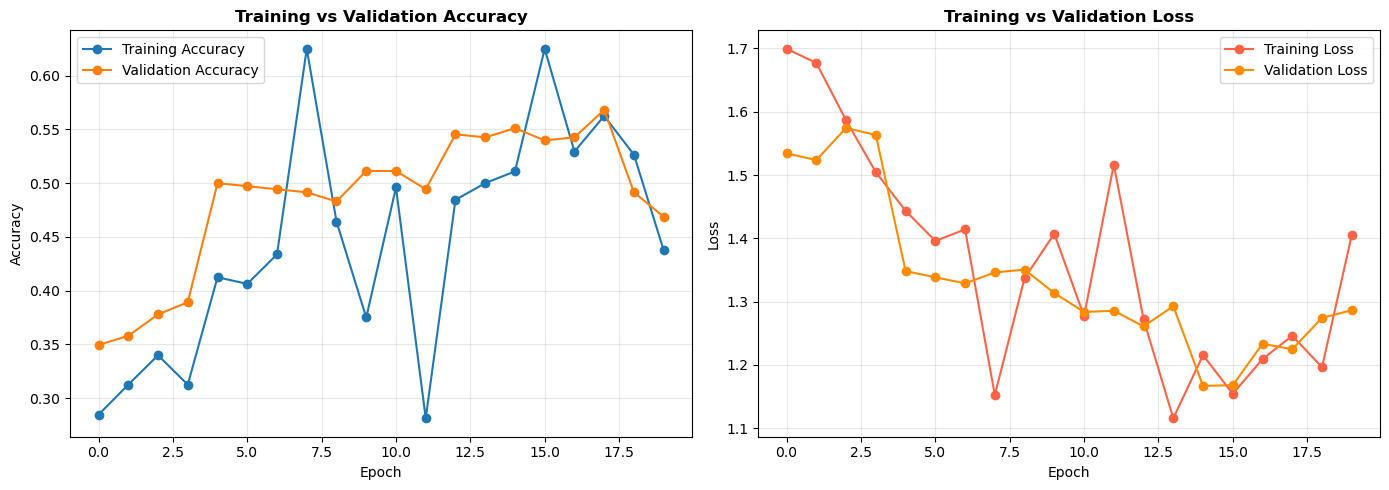

Training Accuracy akhir   : 0.4375
Validation Accuracy akhir : 0.4688
Selisih (gap)             : -0.0312

Indikasi: model cenderung MENGALAMI UNDERFITTING (akurasi training dan validation keduanya rendah).


In [19]:
# ==========================================================
# GRAFIK ACCURACY & LOSS SELAMA TRAINING
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Grafik Loss
axes[1].plot(history.history['loss'], label='Training Loss', marker='o', color='tomato')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o', color='darkorange')
axes[1].set_title('Training vs Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# DIAGNOSIS OVERFITTING / UNDERFITTING SECARA OTOMATIS
# ==========================================================
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print(f"Training Accuracy akhir   : {final_train_acc:.4f}")
print(f"Validation Accuracy akhir : {final_val_acc:.4f}")
print(f"Selisih (gap)             : {gap:.4f}")

if gap > 0.15:
    print("\nIndikasi: model cenderung MENGALAMI OVERFITTING "
          "(training accuracy jauh lebih tinggi dari validation accuracy).")
elif final_train_acc < 0.6 and final_val_acc < 0.6:
    print("\nIndikasi: model cenderung MENGALAMI UNDERFITTING "
          "(akurasi training dan validation keduanya rendah).")
else:
    print("\nIndikasi: model menunjukkan performa yang cukup SEIMBANG "
          "antara training dan validation (tidak terindikasi overfitting/underfitting yang signifikan).")


## 12. Prediksi Gambar Baru

Bagian ini menyediakan fungsi untuk memprediksi jenis sampah dari sebuah gambar baru yang diunggah oleh pengguna. Fungsi ini akan menampilkan gambar, kelas hasil prediksi, tingkat keyakinan (*confidence*), serta distribusi probabilitas untuk seluruh kelas.

> Pada Google Colab, gunakan `from google.colab import files` untuk mengunggah gambar. Jika dijalankan secara lokal, cukup tentukan path gambar secara langsung.


In [20]:
# ==========================================================
# FUNGSI PREDIKSI GAMBAR BARU
# ==========================================================

def predict_image(img_path, model, class_names, img_size=IMG_SIZE):
    """
    Memuat sebuah gambar baru, melakukan preprocessing yang konsisten
    dengan data training, lalu memprediksi kelasnya menggunakan model CNN.
    """
    # Membaca dan melakukan preprocessing gambar
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_normalized = img_resized.astype("float32") / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Melakukan prediksi
    probs = model.predict(img_input, verbose=0)[0]
    predicted_idx = np.argmax(probs)
    predicted_class = class_names[predicted_idx]
    confidence = probs[predicted_idx] * 100

    # Menampilkan gambar dan hasil prediksi
    plt.figure(figsize=(5, 5))
    plt.imshow(img_resized)
    plt.axis('off')
    plt.title(f"Predicted Class : {predicted_class.capitalize()}\nConfidence : {confidence:.2f}%",
              fontsize=12, fontweight='bold')
    plt.show()

    # Menampilkan probabilitas seluruh kelas
    print(f"Predicted Class : {predicted_class.capitalize()}")
    print(f"Confidence      : {confidence:.2f}%\n")
    print("Probabilitas seluruh kelas:")
    for cls, p in sorted(zip(class_names, probs), key=lambda x: x[1], reverse=True):
        print(f"  {cls.capitalize():10s} : {p*100:.2f}%")

    return predicted_class, confidence, probs


# ==========================================================
# CONTOH PENGGUNAAN DI GOOGLE COLAB (upload gambar manual)
# ==========================================================
# from google.colab import files
# uploaded = files.upload()
# new_img_path = list(uploaded.keys())[0]
# predict_image(new_img_path, model, target_names)

# ==========================================================
# CONTOH PENGGUNAAN SECARA LOKAL (gunakan path gambar langsung)
# ==========================================================
# new_img_path = "contoh_sampah.jpg"
# predict_image(new_img_path, model, target_names)

print("Fungsi predict_image() siap digunakan. "
      "Isi variabel 'new_img_path' dengan path gambar yang ingin diprediksi.")


Fungsi predict_image() siap digunakan. Isi variabel 'new_img_path' dengan path gambar yang ingin diprediksi.


## 13. Analisis Hasil

### 13.1 Kelas dengan Akurasi Terbaik

Berdasarkan *classification report* dan *confusion matrix* pada Bagian 10, kelas dengan nilai diagonal tertinggi pada confusion matrix (relatif terhadap jumlah sampelnya) merupakan kelas yang paling mudah dikenali oleh model. Umumnya, kelas dengan karakteristik visual yang sangat khas dan konsisten — misalnya **metal** (warna metalik mengkilap yang jelas berbeda dari kelas lain) atau **cardboard** (warna coklat dan tekstur bergelombang yang khas) — cenderung memperoleh akurasi klasifikasi yang lebih tinggi dibandingkan kelas lain.

### 13.2 Kelas yang Sering Tertukar

Pasangan kelas yang sering tertukar biasanya memiliki kemiripan visual yang tinggi, contohnya:
- **Glass vs Plastic** — keduanya dapat memiliki permukaan transparan/bening dan bentuk botol yang serupa.
- **Paper vs Cardboard** — keduanya berbahan dasar serat selulosa dengan warna dan tekstur yang mirip.
- **Trash** sering menjadi kelas "campuran" karena berisi objek yang sangat bervariasi, sehingga kemungkinan tertukar dengan kelas lain juga relatif tinggi.

Pola kesalahan ini dapat dilihat secara eksplisit pada nilai-nilai di luar diagonal pada confusion matrix di Bagian 10.

### 13.3 Penyebab Kesalahan Klasifikasi

Beberapa kemungkinan penyebab kesalahan klasifikasi pada model ini antara lain:
1. **Kemiripan visual antar kelas** — beberapa jenis sampah memiliki warna, bentuk, dan tekstur yang serupa sehingga sulit dibedakan hanya dari informasi piksel.
2. **Kualitas dan variasi gambar** — pencahayaan, sudut pengambilan, dan latar belakang gambar yang bervariasi dapat memengaruhi fitur yang diekstraksi oleh model.
3. **Ketidakseimbangan jumlah data** (*class imbalance*) — kelas dengan jumlah sampel yang lebih sedikit (misalnya `trash`) cenderung lebih sulit dipelajari model secara optimal dibandingkan kelas dengan jumlah sampel yang lebih banyak.
4. **Keterbatasan kapasitas model** — karena model dibangun dari awal (bukan transfer learning) dengan arsitektur yang relatif sederhana, kemampuannya mengekstraksi fitur kompleks mungkin tidak sebaik model yang telah dilatih pada dataset berskala besar (misalnya ImageNet).

### 13.4 Pengaruh Jumlah Data terhadap Performa

Jumlah data pada setiap kelas memiliki pengaruh langsung terhadap performa model. Kelas dengan jumlah sampel yang lebih banyak memberikan lebih banyak variasi contoh bagi model untuk dipelajari, sehingga umumnya menghasilkan performa klasifikasi yang lebih baik dan lebih stabil. Sebaliknya, kelas dengan jumlah sampel terbatas (lihat distribusi data pada Bagian 4) berisiko menyebabkan model kurang mampu menggeneralisasi pola visual kelas tersebut, yang berpotensi menurunkan nilai *recall* untuk kelas yang bersangkutan. Hal ini dapat diatasi pada penelitian lanjutan dengan menambah jumlah data, menerapkan teknik *class weighting*, atau melakukan augmentasi data yang lebih agresif khusus pada kelas minoritas.


## 14. Kesimpulan

Berdasarkan keseluruhan proses yang telah dilakukan, dapat disimpulkan beberapa hal berikut:

1. **Convolutional Neural Network (CNN)** terbukti dapat diimplementasikan untuk membangun sistem klasifikasi jenis sampah berbasis citra, dengan memanfaatkan kemampuan CNN dalam mengekstraksi fitur visual secara otomatis melalui operasi convolution, activation, dan pooling.
2. Proses **preprocessing** (resize, normalisasi, label encoding) dan **data augmentation** (rotasi, zoom, flip, shift) berperan penting dalam mempersiapkan data agar model dapat belajar secara optimal dan lebih tahan terhadap variasi kondisi gambar di dunia nyata, sekaligus membantu mengurangi risiko overfitting.
3. Arsitektur CNN yang dibangun dari awal pada proyek ini — yang terdiri dari tiga blok konvolusi (32, 64, 128 filter) yang diikuti dengan fully connected layer dan dropout — mampu mempelajari representasi fitur dari enam kelas sampah yang berbeda, meskipun performanya tetap bergantung pada kualitas dan kuantitas data yang tersedia.
4. Hasil evaluasi menggunakan metrik **accuracy, precision, recall,** dan **F1-score**, serta visualisasi **confusion matrix**, memberikan gambaran objektif mengenai kemampuan model, termasuk mengidentifikasi kelas-kelas yang paling sering tertukar akibat kemiripan visual.
5. Grafik **training history** (accuracy dan loss) menjadi alat diagnosis penting untuk memastikan model tidak mengalami overfitting maupun underfitting secara signifikan, dan dapat digunakan sebagai dasar untuk melakukan tuning hyperparameter lebih lanjut.
6. Sistem klasifikasi otomatis ini berpotensi menjadi fondasi bagi pengembangan **sistem pemilahan sampah otomatis** di lingkungan kampus, yang dapat diintegrasikan dengan perangkat keras seperti kamera dan mekanisme sortasi fisik untuk mendukung pengelolaan sampah yang lebih efisien dan berkelanjutan.

Sebagai pengembangan lebih lanjut, performa model dapat ditingkatkan dengan menambah jumlah dan variasi data (khususnya pada kelas minoritas seperti `trash`), menerapkan teknik *transfer learning* menggunakan model pretrained (misalnya MobileNetV2 atau ResNet50), serta melakukan *hyperparameter tuning* yang lebih sistematis.
